In [4]:
dir()

['In',
 'Out',
 '_',
 '_2',
 '_3',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'exit',
 'get_ipython',
 'open',
 'quit']

                               Feature  Importance
30   marital.status_Married-civ-spouse    0.392067
3                         capital.gain    0.059616
2                        education.num    0.054129
41            occupation_Other-service    0.034612
50              relationship_Own-child    0.026721
4                         capital.loss    0.020838
99                     AgeGroup_Middle    0.017294
37          occupation_Exec-managerial    0.016867
38          occupation_Farming-fishing    0.016203
39        occupation_Handlers-cleaners    0.016172
46             occupation_Tech-support    0.015536
43           occupation_Prof-specialty    0.013073
52                   relationship_Wife    0.011884
49         relationship_Other-relative    0.010768
0                                  age    0.010602
57                            sex_Male    0.009873
40        occupation_Machine-op-inspct    0.009669
29    marital.status_Married-AF-spouse    0.009225
5                       hours.p

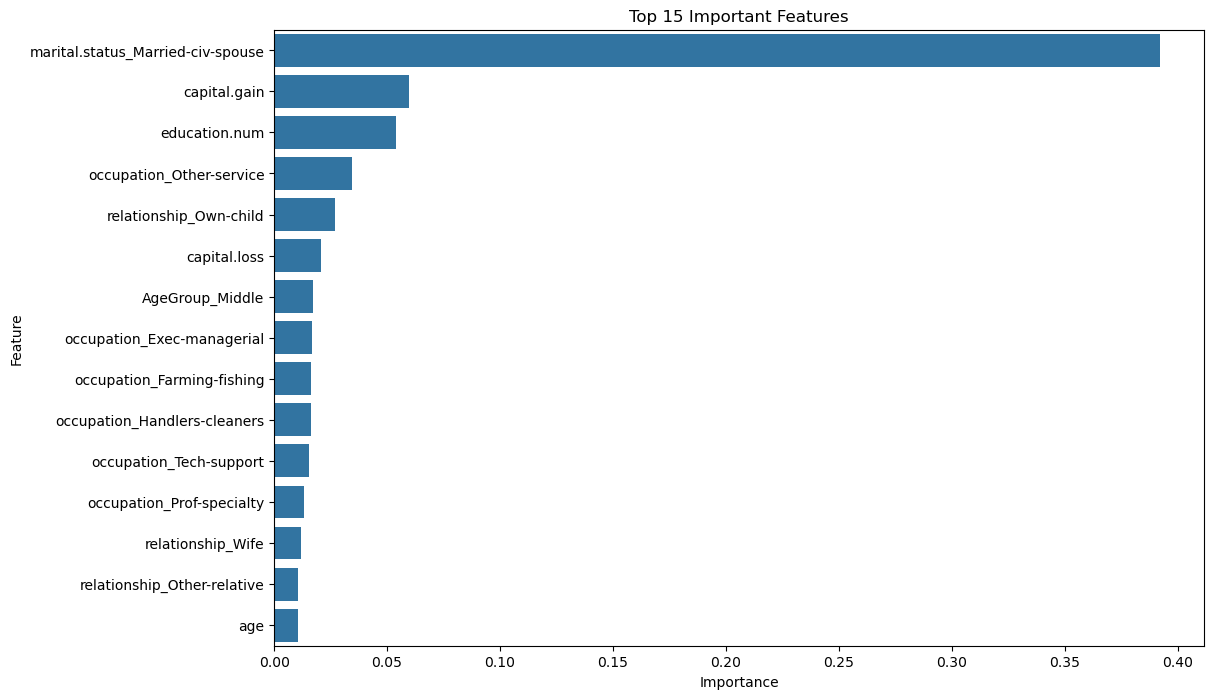

Feature Importance Saved Successfully


In [5]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================

df = pd.read_csv(
    "../data/processed/engineered_adult.csv"
)

# =========================
# DEFINE FEATURES
# =========================

X = df.drop(
    "income",
    axis=1
)

# =========================
# LOAD BEST MODEL
# =========================

xgb = joblib.load(
    "../models/best_model.pkl"
)

# =========================
# FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

# =========================
# VISUALIZATION
# =========================

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

# =========================
# SAVE REPORT
# =========================

importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature Importance Saved Successfully")